In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib as mpl


from pathlib import Path
import scipy
import numpy as np
import pandas as pd
import datetime as dt
import soundfile as sf
import ipywidgets as widgets

import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

In [2]:
import UBNA_localize_process_GCC__20250505 as localize

In [3]:
SAMPLERATE = 250000
NUM_CHANNELS = 8
BYTES_PER_SAMPLE = 2 #int16

COLOR_MAP_FOR_TRAJ = {0:cm.Blues, 1:cm.Reds, 2:cm.Greens}
MIC_MARKER_THICKNESS = 2
POINT_SIZE = 75

In [4]:
GRID_SIZE = 40
CIRCLE_RADIUS = 10
SOUND_SPEED_AIR = 343
TIME_DURATION = 0.2
RCVR_COLORS = ['red', 'limegreen', 'blue', 'mediumpurple', 'slategray', 'brown', 'green', 'darkred']
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=RCVR_COLORS)
COLOR_CYCLE = plt.rcParams['axes.prop_cycle'].by_key()['color']
BAT_INIT_DIST = 10

FS = 250000
ASSUMED_BAT_SPEED = 4 # m/s
ASSUMED_BAT_IPI = 0.1 # secs (100ms)
TIMESTEPS = np.arange(0, ((2*BAT_INIT_DIST)/ASSUMED_BAT_SPEED) + ASSUMED_BAT_IPI, ASSUMED_BAT_IPI)

In [5]:
ZMAG_REF_TO_6 = 29.125
ZMAG_REF_TO_7 = 31.6875
XMAG_REF_TO_1 = 17.7
YMAG_REF_TO_6 = 21
YMAG_REF_TO_1 = 37.5
UBNA_ARRAY_MIC_LOCS =  (254/10000) * np.array([[-XMAG_REF_TO_1, -YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, ZMAG_REF_TO_7],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_1, 0],
                    [-XMAG_REF_TO_1, -YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [-XMAG_REF_TO_1, YMAG_REF_TO_6, -ZMAG_REF_TO_6],
                    [0, 0, ZMAG_REF_TO_7],
                    [0, 0, 0]])
UBNA_ARRAY_MIC_LOCS

array([[-0.44958  , -0.9525   ,  0.8048625],
       [-0.44958  ,  0.9525   ,  0.8048625],
       [-0.44958  , -0.9525   ,  0.       ],
       [-0.44958  ,  0.9525   ,  0.       ],
       [-0.44958  , -0.5334   , -0.739775 ],
       [-0.44958  ,  0.5334   , -0.739775 ],
       [ 0.       ,  0.       ,  0.8048625],
       [ 0.       ,  0.       ,  0.       ]])

In [6]:
%matplotlib inline

SELECTED_CHANNEL_FOR_REF = 7
MICROPHONES_USED = np.array([1,2,3,4,5,6,7,8])
IND_OF_SELECTED_CHANNEL = np.where(MICROPHONES_USED==(SELECTED_CHANNEL_FOR_REF+1))[0]
SELECTED_MIC_FOR_REF = MICROPHONES_USED[IND_OF_SELECTED_CHANNEL]
NON_REF_MICROPHONES_USED = MICROPHONES_USED[MICROPHONES_USED!=SELECTED_MIC_FOR_REF]
NUM_GOOD_CHANNELS = MICROPHONES_USED.shape[0]
NUM_NONREFCHANNELS = NUM_GOOD_CHANNELS-1

In [7]:
SNR_CALC_LENGTH = 0.030
SNR_OFFSET_BEFORE_CALL = 0.015
TIME_PAD_FOR_ECHO = 0.002
CORR_LENGTH = 0.025
SPEC_NFFT = 32
COND_VALUE_THRESH = 70

In [8]:
%matplotlib inline

FILE_DIR = Path('/Volumes/UBNA_017/UBNA_array_tests2025/mic_array_test_20250501/inUBNA/array')
site_key = 'Carp'
freq_key = ''

start_stop_file = (FILE_DIR / 'Start_Stop_Times.txt')
with open(start_stop_file, "r", encoding="utf-8") as file:
    content = file.read()
    print(content)
    
start_stop_arr = content.split('\n')
start_of_session = start_stop_arr[0]
FILE_DATETIME = dt.datetime.strptime(start_of_session, 'Start time: %H:%M:%S %m/%d/%y UTC')

FILE_DURATION = 600
HOUR_TAG = 'hour_0'

FILE_OFFSET = 2400
FILE_TIME_TAG = f'{int(FILE_OFFSET)}to{int(FILE_OFFSET+FILE_DURATION)}'
DIR_NAME = f'{HOUR_TAG}_{FILE_TIME_TAG}'
WRITE_DIR = FILE_DIR / DIR_NAME
WRITE_FILE = WRITE_DIR / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'

Start time: 03:30:14 05/02/25 UTC
Stop time: 04:38:26 05/02/25 UTC



In [9]:
def run_pipeline_on_file(file, cfg):
    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    filepath = (cfg['output_dir'] / f'{cfg["csv_filename"]}.csv')
    bd_preds = pd.read_csv(filepath)

    return bd_preds


def get_dets_observed_from_all_channels(file_dir, file_offset):
    cfg = dict()
    cfg['output_dir'] = WRITE_DIR

    channel_dets = pd.DataFrame()
    for selected_channel in range(NUM_CHANNELS):
        write_file_for_indiv_channel = WRITE_DIR / f'{HOUR_TAG}_channel{selected_channel}_{FILE_TIME_TAG}.WAV'
        cfg['input_audio'] = Path(write_file_for_indiv_channel)
        dets = run_pipeline_on_file(write_file_for_indiv_channel, cfg)
        plot_dets = dets.copy()
        plot_dets['start_time'] += file_offset
        plot_dets['end_time'] += file_offset
        channel_dets = pd.concat([channel_dets, plot_dets])

    return channel_dets

In [10]:
CHANNEL_DETS = get_dets_observed_from_all_channels(FILE_DIR, FILE_OFFSET)
CHANNEL_DETS.sort_values(by='start_time', inplace=True)
CHANNEL_DETS.reset_index(drop=True, inplace=True)
CHANNEL_DETS['freq_group'] = CHANNEL_DETS['KMEANS_CLASSES']
CHANNEL_DETS['call_start_time'] = pd.to_timedelta(CHANNEL_DETS['start_time']*1e9) + FILE_DATETIME
CHANNEL_DETS['cycle_ref_time'] = pd.to_timedelta(CHANNEL_DETS['start_time']*1e9) + FILE_DATETIME
CHANNEL_DETS['call_end_time'] = pd.to_timedelta(CHANNEL_DETS['end_time']*1e9) + FILE_DATETIME
CHANNEL_DETS['start_time_wrt_ref'] = CHANNEL_DETS['start_time']
CHANNEL_DETS['end_time_wrt_ref'] = CHANNEL_DETS['end_time']
CHANNEL_THRESH_DETS = CHANNEL_DETS[(CHANNEL_DETS['det_prob']>0.55)].copy()

In [11]:
write_file_for_indiv_channel = WRITE_DIR / f'{HOUR_TAG}_channel{SELECTED_CHANNEL_FOR_REF}_{FILE_TIME_TAG}.WAV'
csv_filename = f"batdetect2_pipeline_{write_file_for_indiv_channel.name.split('.')[0]}"
filepath = (WRITE_DIR/ f'{csv_filename}.csv')
SELECTED_CHANNEL_DETS = pd.read_csv(filepath)
SELECTED_CHANNEL_DETS['start_time'] += FILE_OFFSET
SELECTED_CHANNEL_DETS['end_time'] += FILE_OFFSET
SELECTED_CHANNEL_THRESH_DETS = SELECTED_CHANNEL_DETS[(SELECTED_CHANNEL_DETS['det_prob']>0.55)].copy()

In [12]:
def remove_overlapping_events(channel_dets, OVERLAP_TIME_THRESHOLD=8e-3):

    dist_mat_comp_batdetect2_df = channel_dets.copy()
    association_mat = np.ones((len(dist_mat_comp_batdetect2_df), len(dist_mat_comp_batdetect2_df)), dtype='bool')
    for index in range(len(dist_mat_comp_batdetect2_df)):
        row = dist_mat_comp_batdetect2_df.iloc[index]
        dist_to_all_calls = ((dist_mat_comp_batdetect2_df['start_time'] - row['start_time']).values)

        considered_inds = np.where(np.abs(dist_to_all_calls)<=OVERLAP_TIME_THRESHOLD)[0]
        considered_dets = channel_dets.iloc[considered_inds]

        det_choices = np.zeros(len(considered_inds))
        likely_call_ind = considered_dets['det_prob'].argmax()

        det_choices[likely_call_ind] = 1
        association_mat[considered_inds, index] = det_choices

    removed_overlaps = channel_dets[np.logical_and.reduce(association_mat, axis=1)]

    return removed_overlaps

In [13]:
removed_overlaps = remove_overlapping_events(CHANNEL_THRESH_DETS, OVERLAP_TIME_THRESHOLD=8e-3)
removed_overlaps.to_csv(f'ARRAY_20250530_{DIR_NAME}_OVERLAPS_REMOVED.csv', sep=',', index=False)

REMOVED_OVERLAPS = pd.read_csv(f'ARRAY_20250530_{DIR_NAME}_OVERLAPS_REMOVED.csv')

In [14]:
def clean_section_to_remove_noise(section, spec_features):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(spec_features['NFFT']))
    f, t, Zxx = scipy.signal.stft(section, FS, detrend=False,
                                nperseg=spec_features['NFFT'],
                                nfft=spec_features['NFFT'], 
                                window=mpl_specgram_window)
    Sxx_mag = np.abs(Zxx)
    Sxx_phase = np.angle(Zxx)
    Sxx_mag[np.where(Sxx_mag==0)] = 1e-16
    plt_Sxx_dB = 20 * np.log10(Sxx_mag)
    frame_max_dB = np.max(plt_Sxx_dB, axis=0)  # shape (time,)
    threshold_dB = frame_max_dB - 6
    cleaned_Sxx_dB = np.where(plt_Sxx_dB < threshold_dB[np.newaxis,:], -80, plt_Sxx_dB)
    cleaned_Sxx_mag = 10 ** (cleaned_Sxx_dB / 20)

    Zxx_reconstructed = cleaned_Sxx_mag * np.exp(1j * Sxx_phase)
    _, signal_reconstructed = scipy.signal.istft(Zxx_reconstructed, fs=FS,
                                                window=mpl_specgram_window,
                                                nperseg=spec_features['NFFT'],
                                                nfft=spec_features['NFFT'])

    return signal_reconstructed, _

def extract_call_starts_for_call(call_segment, approx_call_dur):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(SPEC_NFFT))
    f, t, Sxx = scipy.signal.spectrogram(call_segment, FS, detrend=False,
                                nfft=SPEC_NFFT, 
                                window=mpl_specgram_window)
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    found_call_dur = int(FS*(approx_call_dur+0.002))
    found_call_start = int(FS*(peak_freq_time[0] - 0.004))
    return found_call_start, found_call_dur

def snr_quality_metric(snrcb, snreb, snrce):
    return abs((snrcb+snreb)/(snrce))

def extract_reference_call_only(ref_call_segment, approx_call_dur):
    mpl_specgram_window = plt.mlab.window_hanning(np.ones(SPEC_NFFT))
    f, t, Sxx = scipy.signal.spectrogram(ref_call_segment, FS, detrend=False,
                                nfft=SPEC_NFFT, 
                                window=mpl_specgram_window)
    plt_Sxx = 10*np.log10(Sxx)
    max_ind = np.where(plt_Sxx==np.max(plt_Sxx))
    max_value_across_bins = Sxx[max_ind]
    peak_freq = f[max_ind[0]]
    peak_freq_time = t[max_ind[1]]

    found_call_dur = int(FS*(approx_call_dur))
    found_call_start = max(0, int(FS*(peak_freq_time[0] - 0.0045)))
    
    found_call_end = (found_call_start+found_call_dur)
    ref_mic_call_only = ref_call_segment[found_call_start:found_call_end]

    return ref_mic_call_only, found_call_start/FS, found_call_dur/FS

def index_reference_call_based_on_feature_to_maximize(calls, detection_index, feature):
    return calls[detection_index, np.argmax(feature[detection_index]),:], np.argmax(feature[detection_index])

TEMPLATE_CHANNEL = 3
def index_reference_call_based_on_channel(calls, detection_index, channel):
    return calls[detection_index, channel,:], channel

In [26]:
start=0
length=60
time_step=1000
template_channel=4
elevation=90
azim=0

recorded_audio = sf.SoundFile(WRITE_FILE)
recorded_audio.seek(int(FS*start))
audio_seg = recorded_audio.read(int(FS*length))
highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, FS, 20000)

# print(f'Currently at {WRITE_FILE}')
audio_features = dict()
audio_features['figsize'] = (15, 3)
audio_features['file_path'] = WRITE_FILE
audio_features['audio_seg'] = highpassed_audio_seg
audio_features['sample_rate'] = FS
audio_features['start'] = start
audio_features['file_offset'] = FILE_OFFSET
audio_features['duration'] = length

spec_features = dict()
spec_features['NFFT'] = 512 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
spec_features['vmin'] = -90
spec_features['vmax'] = 0

plot_channel_dets = CHANNEL_DETS.loc[(CHANNEL_DETS['start_time']>=(FILE_OFFSET+start))&(CHANNEL_DETS['end_time']<=(FILE_OFFSET+start+length))]
plot_dets = REMOVED_OVERLAPS.loc[(REMOVED_OVERLAPS['start_time']>=(FILE_OFFSET+start))&(REMOVED_OVERLAPS['end_time']<=(FILE_OFFSET+start+length))]
plot_channel_thresh_dets = CHANNEL_THRESH_DETS.loc[(CHANNEL_THRESH_DETS['start_time']>=(FILE_OFFSET+start))&(CHANNEL_THRESH_DETS['end_time']<=(FILE_OFFSET+start+length))]
base_set_for_tdoa = plot_dets[plot_dets['SNR']>=3].copy()
base_set_for_tdoa.insert(1, 'freq_bandwidth', base_set_for_tdoa['high_freq'] - base_set_for_tdoa['low_freq'])
threshSNR_for_section = 0.5*base_set_for_tdoa['SNR'].max()
print(threshSNR_for_section)
better_set_for_tdoa = base_set_for_tdoa[base_set_for_tdoa['freq_bandwidth']>=5000].copy()
set_for_tdoa = better_set_for_tdoa[better_set_for_tdoa['SNR']>=threshSNR_for_section].copy()

23.194840458735946


In [27]:
A_LOCS_MAT = UBNA_ARRAY_MIC_LOCS
A_locs_mat_wrt_ref_channel = A_LOCS_MAT
A_locs_mat_tdoa_meters = A_locs_mat_wrt_ref_channel[(NON_REF_MICROPHONES_USED-1)]

x0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][0]
y0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][1]
z0 = A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF][2]
xm = A_locs_mat_tdoa_meters[:,0].reshape((NUM_NONREFCHANNELS, 1))
ym = A_locs_mat_tdoa_meters[:,1].reshape((NUM_NONREFCHANNELS, 1))
zm = A_locs_mat_tdoa_meters[:,2].reshape((NUM_NONREFCHANNELS, 1))

example_calls = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS, int(FS*SNR_CALC_LENGTH)), dtype=np.float64)
example_call_snrs = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
example_snr_facs = np.zeros((set_for_tdoa.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
example_det_durs = np.zeros(set_for_tdoa.shape[0], dtype=np.float64)
examining_df = set_for_tdoa.copy().iloc[:time_step].reset_index(drop=True)
for channel_num in (MICROPHONES_USED-1):
    for i, det in examining_df.iterrows():
        start = det['start_time'] - FILE_OFFSET - SNR_OFFSET_BEFORE_CALL
        approx_call_dur = localize.get_approx_call_dur(det)
        example_det_durs[i] = max(0.006, approx_call_dur)

        write_file = WRITE_DIR / f'{HOUR_TAG}_channel{channel_num}_{FILE_TIME_TAG}.WAV'
        
        filtered_det = localize.extract_highpassed_detection_from_wavfilepath(write_file, start, SNR_CALC_LENGTH, det)
        found_call_start, found_call_dur = extract_call_starts_for_call(filtered_det, approx_call_dur)
        found_call_end = (found_call_start+found_call_dur)
        echo_pad = int(FS*TIME_PAD_FOR_ECHO)
        found_call, found_background, found_echo = localize.extract_approx_call_windows_for_snr_calcs(filtered_det, 
                                                                                                found_call_start, 
                                                                                                found_call_dur)
        snrce = localize.get_snr_from_band_limited_signal(found_call, found_echo)
        snrcb = localize.get_snr_from_band_limited_signal(found_call, found_background)
        snreb = localize.get_snr_from_band_limited_signal(found_echo, found_background)
        
        example_calls[i, channel_num,:] = filtered_det
        example_call_snrs[i, channel_num] = snrcb
        example_snr_facs[i, channel_num] = snr_quality_metric(snrcb, snreb, snrce)

example_t_delays_wrt_selected_channel = np.zeros((examining_df.shape[0], NUM_GOOD_CHANNELS), dtype=np.float64)
channel_num = 0
for non_ref_call_i in range(NUM_GOOD_CHANNELS):
    for det_num in range(examining_df.shape[0]):
        nonref_dets = example_calls[det_num]
        approx_call_dur = example_det_durs[det_num]
        ref_call_of_det, ref_channel_num = index_reference_call_based_on_channel(example_calls, det_num, template_channel)
        cleaned_template_det, fc_t = clean_section_to_remove_noise(ref_call_of_det, spec_features)
        ref_mic_call_only, found_call_start, found_call_dur = extract_reference_call_only(cleaned_template_det, approx_call_dur)
        raw_signal1 = nonref_dets[non_ref_call_i, :]
        signal1, fc_t = clean_section_to_remove_noise(raw_signal1, spec_features)
        signal2 = ref_mic_call_only
        cross_correlation = scipy.signal.correlate((signal1), (signal2), mode='full')
        lags = scipy.signal.correlation_lags(len(signal1), len(signal2), mode='full')
        max_lag_index = np.argmax(cross_correlation)
        time_delay_in_samples = lags[max_lag_index]
        time_delay_in_seconds = time_delay_in_samples / FS
        example_t_delays_wrt_selected_channel[det_num, non_ref_call_i] = time_delay_in_seconds

time_received_at_rn = example_t_delays_wrt_selected_channel[:time_step]
t_delay_ref_to_selected_channel = time_received_at_rn[:,IND_OF_SELECTED_CHANNEL]
time_delay_mics_to_selected_ref_channel = (time_received_at_rn[:]) - (t_delay_ref_to_selected_channel.reshape((len(t_delay_ref_to_selected_channel), 1)))
time_delay_mics_to_selected_ref_channel_no_ref = np.delete(time_delay_mics_to_selected_ref_channel, IND_OF_SELECTED_CHANNEL, axis=1)
measured_d_mics_to_ref = (time_delay_mics_to_selected_ref_channel_no_ref * SOUND_SPEED_AIR)

source_locs = np.zeros((4, measured_d_mics_to_ref.shape[0]), dtype=np.float64)
cond_a_vals = np.zeros(measured_d_mics_to_ref.shape[0], dtype=np.float64)
norm = plt.Normalize(vmin=0, vmax=measured_d_mics_to_ref.shape[0])
for i in range(measured_d_mics_to_ref.shape[0]-1):
    measured_dm0_column = measured_d_mics_to_ref[i,:].reshape((NUM_NONREFCHANNELS, 1))
    dm0_column = measured_dm0_column.reshape((NUM_NONREFCHANNELS, 1))
    A_mat = np.hstack(((A_locs_mat_tdoa_meters - A_LOCS_MAT[SELECTED_CHANNEL_FOR_REF]), dm0_column))
    wm0 = ((xm**2 + ym**2 + zm**2) - (x0**2 + y0**2+ z0**2) - (dm0_column**2))/2
    xs, residuals, rank, sing_vals = scipy.linalg.lstsq(A_mat, wm0)
    source_locs[:,i] = xs.reshape((1,4))
    cond_a_vals[i] = np.linalg.cond(A_mat)
    
derivate_cond_a_vals = np.diff(cond_a_vals, prepend=0)
valid_source_locs = source_locs[:,derivate_cond_a_vals<20]
valid_examining_df = examining_df.iloc[derivate_cond_a_vals<20].copy()
valid_examining_df = valid_examining_df.iloc[np.abs(valid_source_locs[3,:])>1].copy()
valid_source_locs = valid_source_locs[:,np.abs(valid_source_locs[3,:])>1]

In [28]:
def simulate_N_receivers(set_for_tdoa, time_step, template_channel, elevation, azim):
    spec_features = dict()
    spec_features['NFFT'] = 256 # When segments are short, NFFT should also be small (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = -80
    spec_features['vmax'] = 0

    N = UBNA_ARRAY_MIC_LOCS.shape[0]
    rN_x = UBNA_ARRAY_MIC_LOCS[:,0]
    rN_y = UBNA_ARRAY_MIC_LOCS[:,1]
    rN_z = UBNA_ARRAY_MIC_LOCS[:,2]

    fig = plt.figure(figsize=(15, 10))
    plt.rcParams.update({'font.size':16})
    marker_handles = [Line2D([0], [0], marker='o', color='w', label=f'rcvr #{i+1}', markerfacecolor=COLOR_CYCLE[i], markersize=6) for i in range(N)]
    map_ax_3d = fig.add_subplot(projection='3d')
    map_ax_3d.scatter(rN_x, rN_y, rN_z, s=10, c=COLOR_CYCLE[:N])
    
    for i in range(valid_source_locs.shape[1]):
        line_color = COLOR_MAP_FOR_TRAJ[1](norm(i))
        map_ax_3d.scatter(valid_source_locs[0,i], valid_source_locs[1,i], 
                        valid_source_locs[2,i], color=line_color, edgecolor='k', alpha=1, s=POINT_SIZE/2, zorder=2)

    # map_ax_3d.plot(valid_source_locs[0,:], valid_source_locs[1,:], valid_source_locs[2,:], color='k', alpha=0.5, zorder=1)
    map_ax_3d.set_xlim(-GRID_SIZE / 10, GRID_SIZE / 2)
    map_ax_3d.set_ylim(-GRID_SIZE / 2, GRID_SIZE / 2)
    map_ax_3d.set_zlim(-GRID_SIZE / 10, GRID_SIZE / 2)
    map_ax_3d.set_xlabel("X (meters)")
    map_ax_3d.set_ylabel("Y (meters)")
    map_ax_3d.set_zlabel("Z (meters)")
    map_ax_3d.set_title(f"Sound Reception ({int(N)} receivers; 1 source)")
    map_ax_3d.view_init(elev=elevation, azim=azim)
        
    plt.figure(figsize=(15, 3))
    plt.plot(cond_a_vals, marker='.', label='Cond(A)')
    plt.plot(np.abs(derivate_cond_a_vals), marker='.', label='|diff(Cond(A))|')
    plt.grid(which='both')
    plt.legend()
    plt.ylabel('A condition and change in condition')
    plt.xlabel('Source location time step')
    plt.ylim(-100, 400)

    return valid_examining_df


def plot_colored_dets_over_audio(audio_features, spec_features, plot_dets):
    audio_seg = audio_features['audio_seg']
    fs = audio_features['sample_rate']
    start = audio_features['start']
    file_offset = audio_features['file_offset']
    duration = audio_features['duration']

    vmax = spec_features['vmax']
    vmin = spec_features['vmin']
    cmap = spec_features['cmap']
    nfft = spec_features['NFFT']

    plt.figure(figsize=audio_features['figsize'])
    plt.rcParams.update({'font.size': 16})
    plt.title(f"Spectrogram of {audio_features['plot_title']}", fontsize=24)
    plt.specgram(audio_seg, NFFT=nfft, cmap=cmap, vmin=vmin, vmax=vmax, mode='magnitude', scale='dB')

    ax = plt.gca()
    for i, row in plot_dets.iterrows():
        rect = patches.Rectangle(((row['start_time'] - (start+file_offset))*(fs/2), row['low_freq']/(fs/2)), 
                        (row['end_time'] - row['start_time'])*(fs/2), (row['high_freq'] - row['low_freq'])/(fs/2), 
                        linewidth=2, edgecolor='red', facecolor='none', alpha=0.8)
        # plt.axvline(x=(row['peak_frequency_time_SPECTROGRAM'] - start)*(fs/2), color='w', linestyle='dashed')
        plt.text(x=(row['start_time'] - (start+file_offset))*(fs/2), y=10000/(fs/2), s=f"{round(row['SNR'], 2)}dB"
                 , color='w', fontsize=8, fontweight='bold')
        ax.add_patch(rect)

    plt.yticks(ticks=np.linspace(0, 1, 6), labels=np.linspace(0, fs/2000, 6).astype(int))
    plot_xtype = 'float'
    if (duration > 60):
        plot_xtype = 'int'
    plt.xticks(ticks=np.linspace(0, duration*(fs/2), 11), 
               labels=np.round(np.linspace((start+file_offset), (start+file_offset)+duration, 11, dtype=plot_xtype), 2), rotation=30)
    plt.ylabel("Frequency (kHz)")
    plt.xlabel("Time (s)")
    plt.show()


def plot_audio_bout(start, length, time_step, template_channel, elevation, azim):
    recorded_audio = sf.SoundFile(WRITE_FILE)
    recorded_audio.seek(int(FS*start))
    audio_seg = recorded_audio.read(int(FS*length))
    highpassed_audio_seg = localize.highpass_audio_signal(audio_seg, FS, 20000)

    # print(f'Currently at {WRITE_FILE}')
    audio_features = dict()
    audio_features['figsize'] = (15, 3)
    audio_features['file_path'] = WRITE_FILE
    audio_features['audio_seg'] = highpassed_audio_seg
    audio_features['sample_rate'] = FS
    audio_features['start'] = start
    audio_features['file_offset'] = FILE_OFFSET
    audio_features['duration'] = length

    spec_features = dict()
    spec_features['NFFT'] = 512 # When segments are short, NFFT should also be small to best see calls (must always be > 128)
    spec_features['cmap'] = 'jet' # This colormap shows best contrast between noise and signals
    spec_features['vmin'] = -90
    spec_features['vmax'] = 0

    plot_channel_dets = CHANNEL_DETS.loc[(CHANNEL_DETS['start_time']>=(FILE_OFFSET+start))&(CHANNEL_DETS['end_time']<=(FILE_OFFSET+start+length))]
    plot_dets = REMOVED_OVERLAPS.loc[(REMOVED_OVERLAPS['start_time']>=(FILE_OFFSET+start))&(REMOVED_OVERLAPS['end_time']<=(FILE_OFFSET+start+length))]
    plot_channel_thresh_dets = CHANNEL_THRESH_DETS.loc[(CHANNEL_THRESH_DETS['start_time']>=(FILE_OFFSET+start))&(CHANNEL_THRESH_DETS['end_time']<=(FILE_OFFSET+start+length))]
    base_set_for_tdoa = plot_dets[plot_dets['SNR']>=3].copy()
    base_set_for_tdoa.insert(1, 'freq_bandwidth', base_set_for_tdoa['high_freq'] - base_set_for_tdoa['low_freq'])
    threshSNR_for_section = 0.5*base_set_for_tdoa['SNR'].max()
    print(threshSNR_for_section)
    better_set_for_tdoa = base_set_for_tdoa[base_set_for_tdoa['freq_bandwidth']>=5000].copy()
    better_set_for_tdoa = better_set_for_tdoa[better_set_for_tdoa['SNR']>=threshSNR_for_section].copy()
    audio_features['plot_title'] = f"{audio_features['file_path'].stem} (mic {SELECTED_CHANNEL_FOR_REF+1})"
    set_for_plot = simulate_N_receivers(better_set_for_tdoa, time_step, template_channel, elevation, azim)
    # plot_colored_dets_over_audio(audio_features, spec_features, set_for_plot)

23.194840458735946


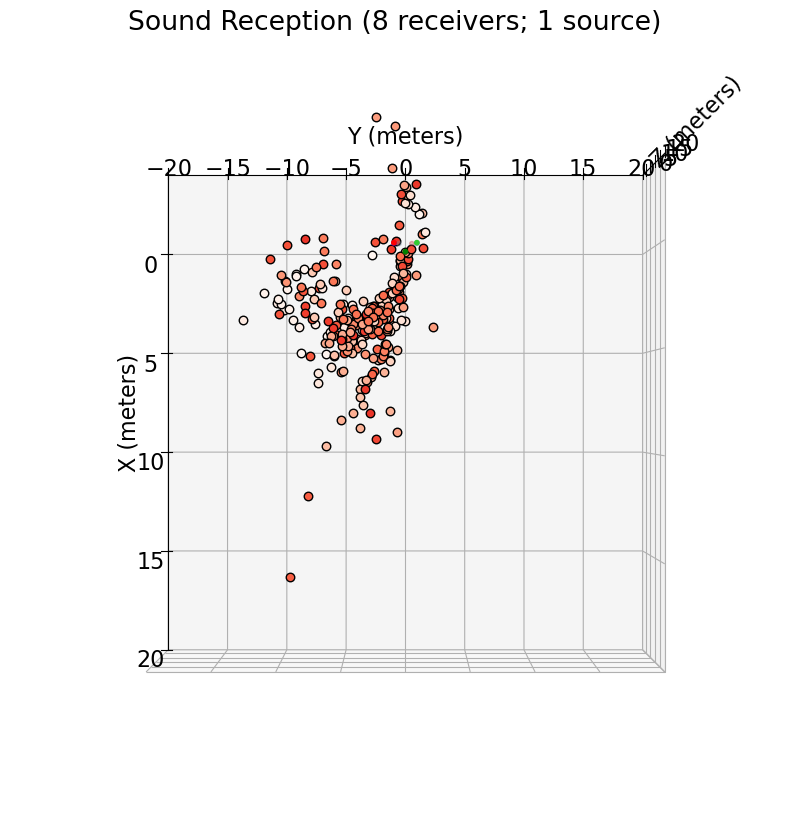

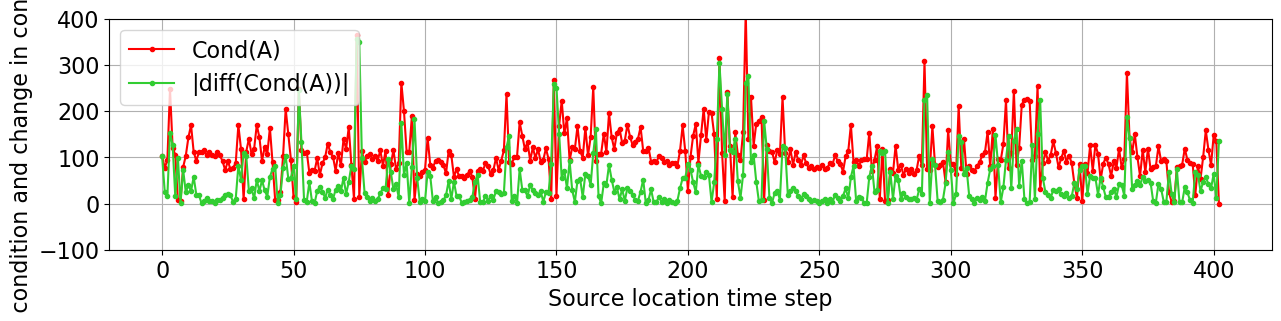

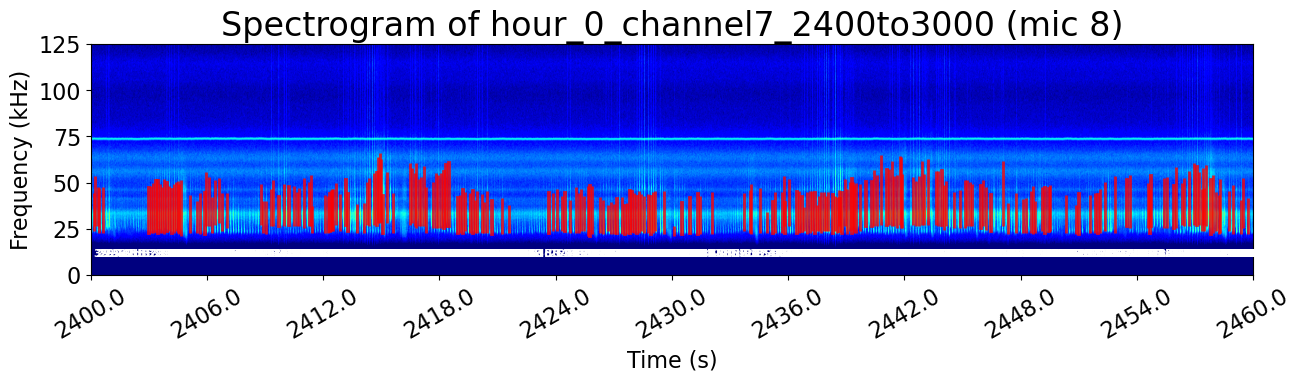

In [97]:
start=0
length=60
time_step=1000
template_channel=4
elevation=90
azim=0
plot_audio_bout(start, length, time_step, template_channel, elevation, azim)

23.194840458735946


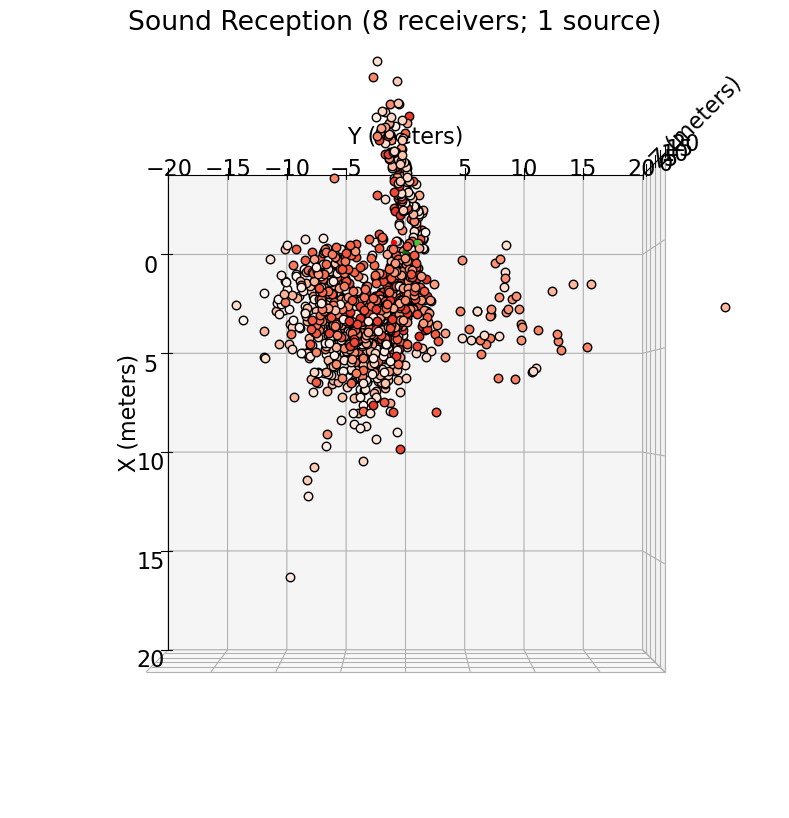

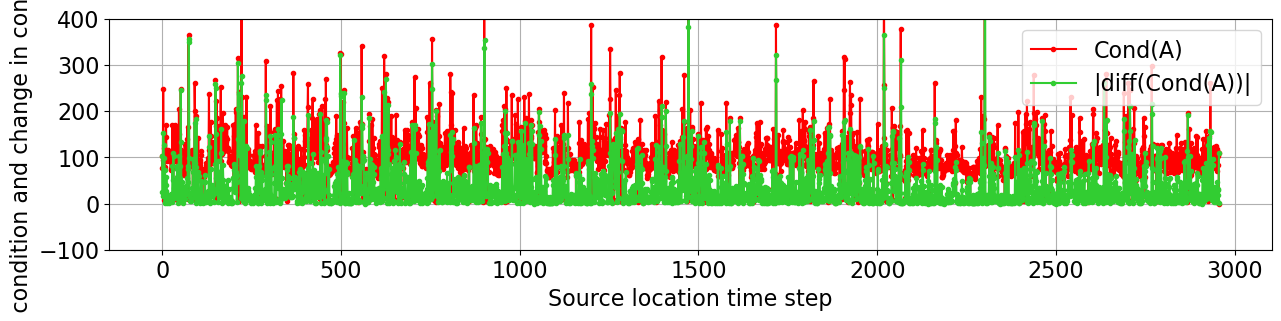

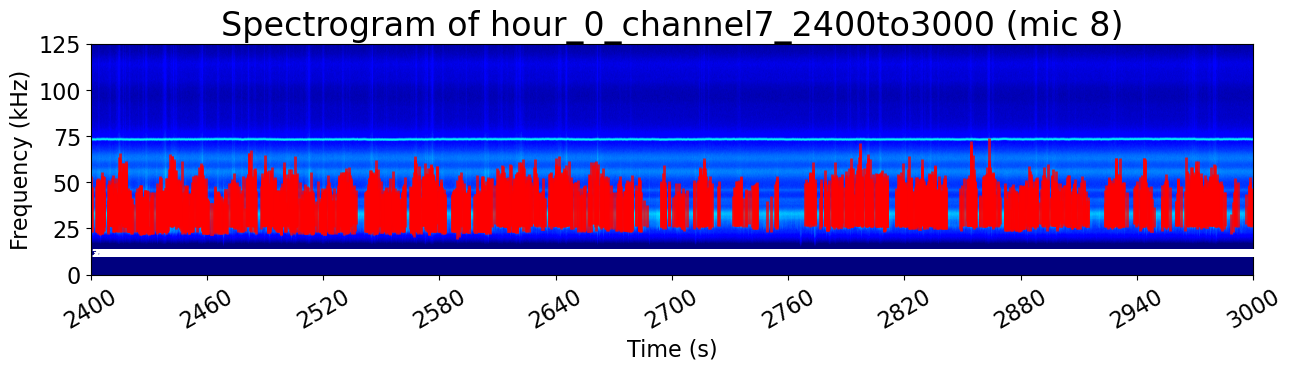

In [95]:
start=0
length=600
time_step=10000
template_channel=4
elevation=90
azim=0
plot_audio_bout(start, length, time_step, template_channel, elevation, azim)

In [29]:
time_step_slider = widgets.IntSlider(
    value=10000, min=0, max=100000, step=1, description="Call (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1500px")
)
template_slider = widgets.IntSlider(
    value=4, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1500px")
)
elevation_slider = widgets.IntSlider(
    value=90, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1500px")
)
azim_slider = widgets.IntSlider(
    value=0, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1500px")
)
start_slider = widgets.FloatSlider(
    value=0, min=0, max=FILE_DURATION-10, step=0.5, description="Spectrogram Start (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1500px")
)
length_slider = widgets.FloatSlider(
    value=600, min=1, max=FILE_DURATION, step=0.5, description="Spectrogram Duration (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1500px")
)

interactive_plot = widgets.interactive(plot_audio_bout, start=start_slider, length=length_slider, time_step=time_step_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=0.0, description='Spectrogram Start (s)', layout=Layout(width='1500px'…

In [66]:
time_step_slider = widgets.IntSlider(
    value=40, min=0, max=100, step=1, description="Call (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
template_slider = widgets.IntSlider(
    value=4, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
elevation_slider = widgets.IntSlider(
    value=90, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
azim_slider = widgets.IntSlider(
    value=0, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
start_slider = widgets.FloatSlider(
    value=2.5, min=0, max=FILE_DURATION-10, step=0.5, description="Spectrogram Start (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1500px")
)
length_slider = widgets.FloatSlider(
    value=2.5, min=1, max=FILE_DURATION, step=0.5, description="Spectrogram Duration (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

interactive_plot = widgets.interactive(plot_audio_bout, start=start_slider, length=length_slider, time_step=time_step_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=2.5, description='Spectrogram Start (s)', layout=Layout(width='1500px'…

In [ ]:
time_step_slider = widgets.IntSlider(
    value=100, min=0, max=100, step=1, description="Call (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
template_slider = widgets.IntSlider(
    value=3, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
elevation_slider = widgets.IntSlider(
    value=30, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
azim_slider = widgets.IntSlider(
    value=0, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
start_slider = widgets.FloatSlider(
    value=427, min=417.5, max=440, step=0.5, description="Spectrogram Start (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
length_slider = widgets.FloatSlider(
    value=10, min=1, max=30, step=1, description="Spectrogram Duration (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

## SCROLL START TIME UNTIL t=435.5s TO SEE BAT TRACK
interactive_plot = widgets.interactive(plot_audio_bout, start=start_slider, length=length_slider, time_step=time_step_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=427.0, description='Spectrogram Start (s)', layout=Layout(width='1000p…

In [18]:
time_step_slider = widgets.IntSlider(
    value=100, min=0, max=100, step=1, description="Call (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
template_slider = widgets.IntSlider(
    value=3, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
elevation_slider = widgets.IntSlider(
    value=30, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
azim_slider = widgets.IntSlider(
    value=0, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
start_slider = widgets.FloatSlider(
    value=418.5, min=417.5, max=440, step=0.5, description="Spectrogram Start (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
length_slider = widgets.FloatSlider(
    value=5, min=1, max=30, step=1, description="Spectrogram Duration (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

## SCROLL START TIME UNTIL t=435.5s TO SEE BAT TRACK
interactive_plot = widgets.interactive(plot_audio_bout, start=start_slider, length=length_slider, time_step=time_step_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=418.5, description='Spectrogram Start (s)', layout=Layout(width='1000p…

In [ ]:
time_step_slider = widgets.IntSlider(
    value=100, min=0, max=100, step=1, description="Call (k)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
template_slider = widgets.IntSlider(
    value=3, min=0, max=NUM_GOOD_CHANNELS-1, step=1, description="Template Channel #", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="800px")
)
elevation_slider = widgets.IntSlider(
    value=30, min=0, max=360, step=1, description="Camera Elevation (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
azim_slider = widgets.IntSlider(
    value=0, min=0, max=360, step=1, description="Camera Azimuth (degrees)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
start_slider = widgets.FloatSlider(
    value=432.5, min=417.5, max=440, step=0.5, description="Spectrogram Start (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)
length_slider = widgets.FloatSlider(
    value=6, min=1, max=30, step=1, description="Spectrogram Duration (s)", continuous_update=True, style={'description_width': 'initial'}, layout=widgets.Layout(width="1000px")
)

## SCROLL START TIME UNTIL t=435.5s TO SEE BAT TRACK
interactive_plot = widgets.interactive(plot_audio_bout, start=start_slider, length=length_slider, time_step=time_step_slider, 
                                       template_channel=template_slider, elevation=elevation_slider, azim=azim_slider)
display(interactive_plot)

interactive(children=(FloatSlider(value=432.5, description='Spectrogram Start (s)', layout=Layout(width='1000p…